# Large-Cap U.S. Technology First-Round Screen

This notebook documents a first-stage quantitative screen prepared for an investment committee review of large U.S. technology stocks. The task is to start from a broad, liquid universe, compare the names on a common historical basis, and reduce that universe to a smaller list worthy of deeper follow-up.

The output is a first-round watchlist, not a final investment recommendation. The emphasis is on defensible filtering: clean data, comparable metrics, and a disciplined narrowing of more than twenty relevant names into a manageable shortlist.


## 1. Executive Brief

The committee has asked for a first quantitative pass across a broad universe of large-cap U.S. technology stocks before the next review cycle.

The immediate need is practical:

- start with a wide enough universe to make the first-round selection meaningful
- use a broad-market benchmark so relative performance is not judged in isolation
- separate the strongest historical profiles from names that may require more caution
- leave valuation, earnings quality, and business-specific due diligence for the next stage

The question for this notebook is therefore straightforward: based on historical market behavior, which names from a 20-plus-stock technology universe currently look strongest as candidates for deeper follow-up?


In [1]:
# Import utility modules for file paths, clean output handling,
# and compatibility across different notebook launch locations.
import contextlib
import io
import sys
from pathlib import Path

# Import the core analysis libraries:
# - matplotlib and seaborn for charts
# - numpy and pandas for calculations and tables
# - yfinance for market-data download
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf

# Use notebook-friendly display tools when available.
# If the notebook is opened in a simpler environment,
# fall back to standard Python printing so the code still works.
try:
    from IPython.display import Markdown, display
except ImportError:
    def display(obj):
        print(obj)

    def Markdown(text):
        return text

# Detect the repository root folder so local files can be found reliably.
PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Set consistent formatting and chart defaults to make the notebook easier to read.
pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

# Define the benchmark and the technology-stock screening universe.
BENCHMARK = "SPY"
WATCHLIST = [
    "AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "AVGO", "ORCL", "CRM", "ADBE",
    "AMD", "CSCO", "QCOM", "TXN", "INTC", "IBM", "NOW", "AMAT", "MU", "PANW",
]

# Combine benchmark and stock universe into one list for later processing.
TICKERS = [BENCHMARK, *WATCHLIST]

# Fix the analysis window to keep results reproducible.
START_DATE = "2022-01-01"
END_DATE = "2025-12-31"

# Point to the local cache file used when live download is unavailable.
CACHE_PATH = PROJECT_ROOT / "data" / "us_tech_watchlist_prices.csv"

# Define a small color system so each status means the same thing across charts.
COLORS = {
    "benchmark": "#1f3b5c",
    "priority": "#0e7490",
    "secondary": "#2a9d8f",
    "monitor": "#d4a373",
    "lower": "#b23a48",
    "neutral": "#7a8b99",
}

# Create a business-facing table describing the universe and why each name is included.
market_universe = pd.DataFrame(
    {
        "Ticker": TICKERS,
        "Sub-sector": [
            "Broad U.S. market benchmark", "Consumer ecosystem", "Enterprise software and cloud",
            "Semiconductors / AI compute", "E-commerce and cloud", "Digital platforms", "Search and cloud",
            "Semiconductors / infrastructure", "Database and enterprise applications", "Enterprise applications",
            "Creative and document software", "Semiconductors / compute", "Networking infrastructure",
            "Wireless semiconductors", "Analog semiconductors", "Semiconductors / manufacturing",
            "IT infrastructure and software", "Workflow software", "Semiconductor equipment",
            "Memory semiconductors", "Cybersecurity",
        ],
        "Why it is in the screen": [
            "Reference point for excess-return comparisons.",
            "Liquid mega-cap franchise and mature platform anchor.",
            "Core institutional software and cloud exposure.",
            "Recent market leadership tied to AI infrastructure demand.",
            "Large-cap growth exposure with uneven post-2021 recovery.",
            "Platform business with strong rebound potential and path risk.",
            "Scaled mega-cap technology compounder.",
            "High-performing semiconductor and infrastructure franchise.",
            "Large-cap software and database exposure.",
            "Scaled SaaS franchise with enterprise spending sensitivity.",
            "Software franchise exposed to digital content demand.",
            "High-beta compute and data-center exposure.",
            "Mature infrastructure and networking exposure.",
            "Wireless and handset semiconductor exposure.",
            "Analog semiconductor exposure with industrial linkages.",
            "Legacy semiconductor name for contrast inside the peer set.",
            "Defensive technology incumbent with improving market profile.",
            "High-growth workflow automation franchise.",
            "Semiconductor equipment exposure to capex cycles.",
            "Memory cycle exposure.",
            "Cybersecurity leader with growth and valuation sensitivity.",
        ],
    }
)

# Summarize the scope of the screening exercise in one compact table.
scope_snapshot = pd.DataFrame(
    {
        "Item": ["Screening horizon", "Universe size", "Frequency", "Benchmark", "Decision use", "Out of scope today"],
        "Definition": [
            f"{START_DATE} to {END_DATE}",
            f"{len(WATCHLIST)} technology stocks plus {BENCHMARK}",
            "Daily market data",
            BENCHMARK,
            "First-stage watchlist for deeper research",
            "Valuation, fundamentals, earnings revisions, and portfolio sizing",
        ],
    }
)

# Convert a decimal number into a readable percentage string.
def pct(value):
    return f"{value * 100:.1f}%"

# Simplify chart borders for a cleaner visual style.
def style_axes(axis):
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

# Convert daily returns into an annualized return estimate.
def annualized_return(return_table, trading_days=252):
    return (1 + return_table).prod() ** (trading_days / len(return_table)) - 1

# Convert daily volatility into annualized volatility.
def annualized_volatility(return_table, trading_days=252):
    return return_table.std() * np.sqrt(trading_days)

# Download market data from Yahoo Finance, or fall back to the local cached file.
def load_market_data(tickers, start_date, end_date, cache_path):
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        raw = yf.download(
            tickers=tickers,
            start=start_date,
            end=end_date,
            auto_adjust=False,
            progress=False,
            threads=False,
        )

    if raw is not None and not raw.empty:
        raw.to_csv(cache_path)
        return raw, "Yahoo Finance live download"

    if cache_path.exists():
        cached = pd.read_csv(cache_path, header=[0, 1], index_col=0, parse_dates=True)
        return cached, f"Local cache fallback ({cache_path.name})"

    raise ValueError("No market data available. Check connectivity or provide the local cache file.")

# Create a presentation-ready copy of a table with selected columns shown as percentages.
def format_table(frame, pct_columns):
    formatted = frame.copy()
    for column in pct_columns:
        formatted[column] = formatted[column].map(lambda value: pct(value) if pd.notna(value) else "--")
    return formatted

## 2. Analytical Scope

The universe is deliberately broad enough to make the first cut credible: a broad U.S. equity benchmark plus twenty large, liquid U.S. technology names spanning platforms, semiconductors, enterprise software, infrastructure, and cybersecurity.

The benchmark matters because a stock can post a positive return and still fail the screening test if it simply tracked the market without generating meaningful excess performance.

This screen is designed to answer four questions:

- which names delivered the strongest total return over the review window
- which names combined return with a more stable path
- which names exposed investors to the deepest historical drawdowns
- which names deserve to survive the first-round screen and move into a smaller follow-up list

It does not answer whether a stock is currently cheap, whether earnings expectations are realistic, or how any name fits a specific portfolio mandate. Those decisions require a second layer of work.


In [2]:
# Display the universe table so the reader can see which names are included.
display(market_universe)

# Display the scope summary so the objective is clear before data work begins.
display(scope_snapshot)

,Ticker,Sub-sector,Why it is in the screen
0,SPY,Broad U.S. market benchmark,Reference point for excess-return comparisons.
1,AAPL,Consumer ecosystem,Liquid mega-cap franchise and mature platform ...
2,MSFT,Enterprise software and cloud,Core institutional software and cloud exposure.
3,NVDA,Semiconductors / AI compute,Recent market leadership tied to AI infrastruc...
4,AMZN,E-commerce and cloud,Large-cap growth exposure with uneven post-202...
5,META,Digital platforms,Platform business with strong rebound potentia...
6,GOOGL,Search and cloud,Scaled mega-cap technology compounder.
7,AVGO,Semiconductors / infrastructure,High-performing semiconductor and infrastructu...
8,ORCL,Database and enterprise applications,Large-cap software and database exposure.
9,CRM,Enterprise applications,Scaled SaaS franchise with enterprise spending...


,Item,Definition
0,Screening horizon,2022-01-01 to 2025-12-31
1,Universe size,20 technology stocks plus SPY
2,Frequency,Daily market data
3,Benchmark,SPY
4,Decision use,First-stage watchlist for deeper research
5,Out of scope today,"Valuation, fundamentals, earnings revisions, a..."


## 3. Data Acquisition

Historical market prices are the correct starting point for a first screen because they show how the market has actually rewarded or penalized each name over time. For a committee triage exercise, price history is not sufficient on its own, but it is the fastest way to separate clear leaders from weaker candidates before deeper company work begins.

The workflow below requests daily OHLCV data and keeps a local cache so the notebook remains reproducible even when live connectivity is unavailable.


In [3]:
# Load the raw market data for all tickers.
# The helper function uses live data when possible and the local cache otherwise.
raw, data_source = load_market_data(TICKERS, START_DATE, END_DATE, CACHE_PATH)

# Sort by date to ensure the time series runs in chronological order.
raw = raw.sort_index()

# Print a compact operational summary of the raw download.
print(f"Data source used: {data_source}")
print(f"Raw shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
print(f"Date range returned: {raw.index.min().date()} to {raw.index.max().date()}")
print(f"Available price fields: {list(raw.columns.get_level_values(0).unique())}")

# Display the first few rows so the reader can inspect the raw structure.
display(raw.head(3))

Data source used: Yahoo Finance live download
Raw shape: 1002 rows x 126 columns
Date range returned: 2022-01-03 to 2025-12-30
Available price fields: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


Price      Adj Close                                                       \
Ticker          AAPL     ADBE     AMAT      AMD     AMZN    AVGO      CRM   
Date                                                                        
2022-01-03  178.1037 564.3700 154.0528 150.2400 170.4045 61.3161 251.7637   
2022-01-04  175.8432 554.0000 152.5405 144.4200 167.5220 62.0186 244.6383   
2022-01-05  171.1659 514.4300 148.0903 136.1500 164.3570 59.4378 224.3758   

Price                                 ...    Volume                      \
Ticker        CSCO    GOOGL      IBM  ...      META      MSFT        MU   
Date                                  ...                                 
2022-01-03 55.4976 143.8030 115.5111  ...  14537900  28865100  18705500   
2022-01-04 54.1364 143.2158 117.1924  ...  15998000  32674300  19725000   
2022-01-05 53.2791 136.6456 117.3622  ...  20564500  40054300  28613100   

Price                                                                    \
Ticker           NOW       NVDA      ORCL     PANW      QCOM        SPY   
Date                                                                      
2022-01-03   5218500  391547000  10644400  7802400   5990200   72668200   
2022-01-04  14903000  527154000  11959000  9586200   8484200   71178700   
2022-01-05  10480500  498064000  11236700  7494000  17141200  104538900   

Price                
Ticker          TXN  
Date                 
2022-01-03  3781500  
2022-01-04  4137500  
2022-01-05  5047400  

[3 rows x 126 columns]

## 4. Data Validation and Quality Control

Screening work only helps the committee if the comparison base is trustworthy. Missing observations, broken date alignment, or inconsistent price fields can distort return and risk metrics before interpretation even begins.

The checks below focus on the issues that would most directly undermine a cross-sectional comparison:

- complete date coverage by ticker
- consistent first and last valid observations
- limited or no missing values
- no duplicate timestamps
- visibility on whether `Adj Close` differs materially from `Close`

If this layer is weak, every downstream conclusion is weak by construction.


In [4]:
# Read the available field names so we can choose the most suitable price series.
available_fields = list(raw.columns.get_level_values(0).unique())

# Prefer adjusted close because it is usually the best base for multi-period comparisons.
selected_price_field = "Adj Close" if "Adj Close" in available_fields else "Close"

# Keep only the chosen price panel and sort it by date again for safety.
selected_panel = raw[selected_price_field].copy().sort_index()

# Count how often adjusted and unadjusted close differ.
# This helps explain why adjusted prices matter in longer-period analysis.
if {"Adj Close", "Close"}.issubset(set(available_fields)):
    close_vs_adjusted = (raw["Close"].round(6) != raw["Adj Close"].round(6)).sum()
else:
    close_vs_adjusted = pd.Series(np.nan, index=TICKERS)

# Build a ticker-level quality-control table.
quality_control_table = pd.DataFrame(index=TICKERS)
quality_control_table["First valid date"] = selected_panel.apply(lambda series: series.first_valid_index().date())
quality_control_table["Last valid date"] = selected_panel.apply(lambda series: series.last_valid_index().date())
quality_control_table["Missing observations"] = selected_panel.isna().sum()
quality_control_table["Coverage ratio"] = selected_panel.notna().mean()
quality_control_table["Days Adj Close != Close"] = close_vs_adjusted.reindex(TICKERS)

# Measure the calendar gap between one row and the next to spot unusual breaks.
calendar_gaps = raw.index.to_series().diff().dt.days.dropna()

# Build a dataset-level structural summary.
structural_checks = pd.Series(
    {
        "Selected price field": selected_price_field,
        "Duplicate dates": int(raw.index.duplicated().sum()),
        "Rows with any missing selected price": int(selected_panel.isna().any(axis=1).sum()),
        "Largest calendar gap between observations (days)": int(calendar_gaps.max()),
        "Gaps above four calendar days": int((calendar_gaps > 4).sum()),
    },
    name="Value",
)

# Display both the ticker-level and dataset-level quality checks.
display(quality_control_table)
display(structural_checks.to_frame())

,First valid date,Last valid date,Missing observations,Coverage ratio,Days Adj Close != Close
SPY,2022-01-03,2025-12-30,0,1.0000,1002
AAPL,2022-01-03,2025-12-30,0,1.0000,1002
MSFT,2022-01-03,2025-12-30,0,1.0000,1002
NVDA,2022-01-03,2025-12-30,0,1.0000,1002
AMZN,2022-01-03,2025-12-30,0,1.0000,0
META,2022-01-03,2025-12-30,0,1.0000,1002
GOOGL,2022-01-03,2025-12-30,0,1.0000,1002
AVGO,2022-01-03,2025-12-30,0,1.0000,1002
ORCL,2022-01-03,2025-12-30,0,1.0000,1002
CRM,2022-01-03,2025-12-30,0,1.0000,1002


,Value
Selected price field,Adj Close
Duplicate dates,0
Rows with any missing selected price,0
Largest calendar gap between observations (days),4
Gaps above four calendar days,0


## 5. Canonical Price Table Preparation

The notebook now moves from raw download to the single price table that will support every comparison. `Adj Close` is preferred when available because it absorbs stock splits and cash distributions, which makes multi-period return comparisons more reliable than raw closing prices.

The cleaning approach stays conservative:

- use one price field for every asset
- allow only a one-day forward fill for isolated gaps
- keep only dates where the full cross-section is available

That produces one canonical table from which returns, drawdowns, rankings, and correlations can be traced back without ambiguity.


In [5]:
# Start from the selected price field only.
# This becomes the clean base material for the comparable analysis table.
raw_prices = selected_panel.copy()

# Forward-fill only one day at most.
# This repairs isolated missing values without treating longer gaps as valid data.
aligned_prices = raw_prices.ffill(limit=1)

# Keep only rows where every ticker has a value.
# This ensures the final comparison uses the same dates for all names.
canonical_prices = aligned_prices.dropna(how="any")

# Convert prices into daily percentage returns.
daily_returns = canonical_prices.pct_change().dropna()

# Rebase all series to 100 so different share prices can be compared on one scale.
normalized_index = canonical_prices.divide(canonical_prices.iloc[0]).mul(100)

# Build the full cumulative return path from the daily returns.
cumulative_return_path = (1 + daily_returns).cumprod() - 1

# Compute drawdown, which measures the fall from each stock's own previous peak.
drawdown = canonical_prices.divide(canonical_prices.cummax()) - 1

# Compute the return correlation matrix for the peer group.
correlation_matrix = daily_returns.corr()

# Build the main numeric summary table used later for ranking and selection.
summary_table = pd.DataFrame(index=canonical_prices.columns)
summary_table["Cumulative return"] = normalized_index.iloc[-1] / 100 - 1
summary_table["Annualized return"] = annualized_return(daily_returns)
summary_table["Annualized volatility"] = annualized_volatility(daily_returns)
summary_table["Max drawdown"] = drawdown.min()
summary_table["Current drawdown"] = drawdown.iloc[-1]
summary_table[f"Excess return vs {BENCHMARK}"] = summary_table["Cumulative return"] - summary_table.loc[BENCHMARK, "Cumulative return"]
summary_table[f"Correlation vs {BENCHMARK}"] = correlation_matrix[BENCHMARK]
summary_table["Risk-adjusted return"] = summary_table["Annualized return"] / summary_table["Annualized volatility"]

# Remove the benchmark temporarily so the scoring applies only to the technology names.
tech_summary = summary_table.drop(index=BENCHMARK).copy()

# Build a weighted composite score.
# Lower is better because a lower rank means a stronger screening outcome.
tech_summary["Priority score"] = (
    0.35 * tech_summary["Cumulative return"].rank(ascending=False, method="min")
    + 0.25 * tech_summary[f"Excess return vs {BENCHMARK}"].rank(ascending=False, method="min")
    + 0.30 * tech_summary["Risk-adjusted return"].rank(ascending=False, method="min")
    + 0.10 * tech_summary["Max drawdown"].rank(ascending=False, method="min")
)

# Sort from strongest to weakest according to the composite score.
ranking = tech_summary.sort_values("Priority score").copy()

# Keep the top six names as the first-round shortlist.
shortlist_names = ranking.index[:6].tolist()

# Split the shortlist into immediate priorities and secondary follow-up names.
priority_names = shortlist_names[:3]
secondary_names = shortlist_names[3:6]

# Keep the next four names as monitoring candidates.
monitor_names = ranking.index[6:10].tolist()

# Everyone else falls into lower immediate priority for this round.
lower_priority_names = ranking.index[10:].tolist()

# Start by assigning every stock to the lowest-priority bucket,
# then upgrade names according to the ranking tiers above.
recommendation_map = {ticker: "Lower immediate priority" for ticker in tech_summary.index}
for ticker in monitor_names:
    recommendation_map[ticker] = "Monitor with caution"
for ticker in secondary_names:
    recommendation_map[ticker] = "Secondary follow-up"
for ticker in priority_names:
    recommendation_map[ticker] = "Priority follow-up"

# Build a short natural-language explanation for each stock.
recommendation_reason = {}
for ticker, row in ranking.iterrows():
    if recommendation_map[ticker] == "Priority follow-up":
        recommendation_reason[ticker] = (
            f"Top-tier screen: {pct(row['Cumulative return'])} cumulative return, "
            f"{pct(row[f'Excess return vs {BENCHMARK}'])} versus {BENCHMARK}, "
            f"and strong risk-adjusted efficiency."
        )
    elif recommendation_map[ticker] == "Secondary follow-up":
        recommendation_reason[ticker] = (
            "Strong enough to stay in the first-round shortlist, "
            "but less decisive than the top tier on either volatility or drawdown control."
        )
    elif recommendation_map[ticker] == "Monitor with caution":
        recommendation_reason[ticker] = (
            "Useful comparator for the committee, but either return, volatility, or drawdown "
            "kept it out of the immediate shortlist."
        )
    else:
        recommendation_reason[ticker] = (
            "This window did not produce a competitive enough mix of return and path quality "
            "to justify front-of-queue follow-up."
        )

# Combine the numeric scorecard with the decision labels and written rationale.
final_watchlist = ranking.copy()
final_watchlist["Committee status"] = pd.Series(recommendation_map)
final_watchlist["Screen rationale"] = pd.Series(recommendation_reason)

# Add an explicit display order so the final tables follow business priority order.
status_order = {
    "Priority follow-up": 0,
    "Secondary follow-up": 1,
    "Monitor with caution": 2,
    "Lower immediate priority": 3,
}
final_watchlist["Status order"] = final_watchlist["Committee status"].map(status_order)
final_watchlist = final_watchlist.sort_values(["Status order", "Priority score", "Cumulative return"])

# Keep a short list of names that should be emphasized visually later.
highlight_names = [BENCHMARK, *shortlist_names]

# Summarize how much cleaning happened before the canonical table was built.
canonical_preparation_summary = pd.Series(
    {
        "Price field used": selected_price_field,
        "Rows before alignment": len(raw_prices),
        "Rows after limited forward fill": len(aligned_prices),
        "Rows in canonical table": len(canonical_prices),
        "Rows removed for strict comparability": len(raw_prices) - len(canonical_prices),
        "Canonical date range": f"{canonical_prices.index.min().date()} to {canonical_prices.index.max().date()}",
    },
    name="Value",
)

# Display the data-preparation summary and the first rows of the final price table.
display(canonical_preparation_summary.to_frame())
display(canonical_prices.head())

,Value
Price field used,Adj Close
Rows before alignment,1002
Rows after limited forward fill,1002
Rows in canonical table,1002
Rows removed for strict comparability,0
Canonical date range,2022-01-03 to 2025-12-30


Ticker,AAPL,ADBE,AMAT,AMD,AMZN,AVGO,CRM,CSCO,GOOGL,IBM,...,META,MSFT,MU,NOW,NVDA,ORCL,PANW,QCOM,SPY,TXN
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.1037,564.3700,154.0528,150.2400,170.4045,61.3161,251.7637,55.4976,143.8030,115.5111,...,335.9040,323.1607,93.6140,126.0280,30.0611,82.7432,90.7017,169.1927,450.6445,168.1483
2022-01-04,175.8432,554.0000,152.5405,144.4200,167.5220,62.0186,244.6383,54.1364,143.2158,117.1924,...,333.9097,317.6196,94.1908,120.7880,29.2318,83.6281,87.3333,170.1195,450.4935,168.3248
2022-01-05,171.1659,514.4300,148.0903,136.1500,164.3570,59.4378,224.3758,53.2791,136.6456,117.3622,...,321.6459,305.4267,92.2941,114.5520,27.5491,81.3877,84.1433,169.4562,441.8431,164.8136
2022-01-06,168.3085,514.1200,150.5947,136.2300,163.2540,58.8859,225.8344,53.8447,136.6183,114.9168,...,329.8713,303.0132,93.5162,114.8080,28.1220,81.5766,88.8183,168.9565,441.4280,164.7607
2022-01-07,168.4748,510.7000,145.2680,132.0000,162.5540,57.2331,225.0065,54.0303,135.8939,114.4838,...,329.2066,303.1678,92.3430,113.2780,27.1929,82.6821,87.5817,163.9228,439.6828,158.3029


## 6. Relative Performance Through Time

A normalized price chart is still the cleanest way to compare trajectories when the starting share prices are very different. With a 20-plus-name universe, however, readability becomes a constraint of its own.

To keep the view decision-useful, the chart below shows the full universe but highlights the six names that survived the first quantitative cut. The rest remain visible in the background as context rather than competing for attention.


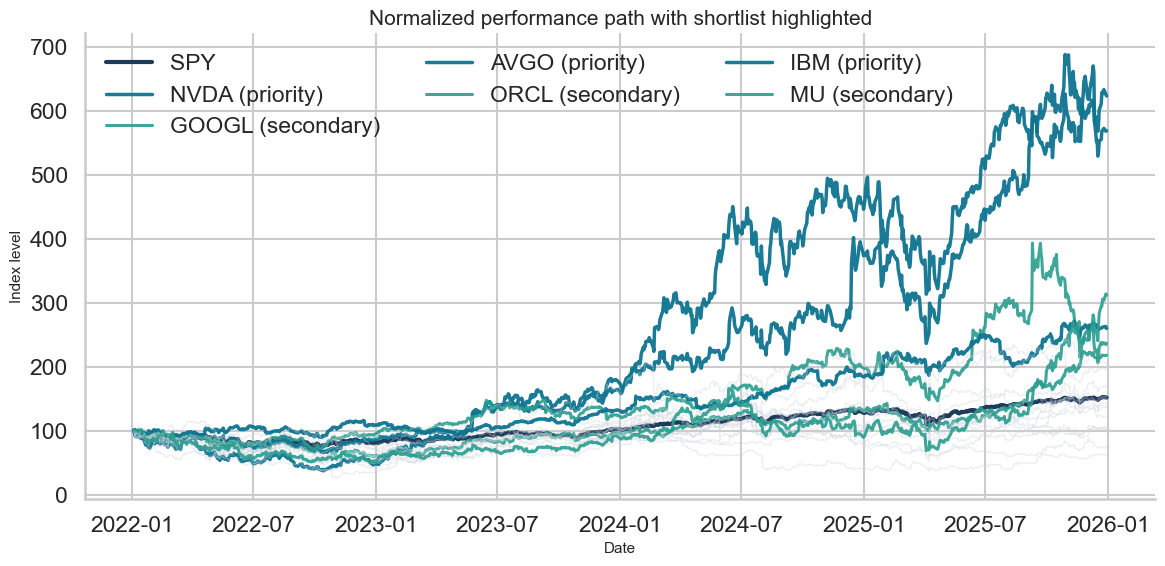

In [6]:
# Create a chart for normalized price paths so all stocks start from the same base.
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each ticker with a visual style that reflects its screening status.
for ticker in TICKERS:
    if ticker == BENCHMARK:
        color = COLORS["benchmark"]
        linewidth = 3.0
        alpha = 1.0
        label = BENCHMARK
    elif ticker in priority_names:
        color = COLORS["priority"]
        linewidth = 2.5
        alpha = 0.95
        label = f"{ticker} (priority)"
    elif ticker in secondary_names:
        color = COLORS["secondary"]
        linewidth = 2.2
        alpha = 0.9
        label = f"{ticker} (secondary)"
    else:
        color = "#c9d1d9"
        linewidth = 1.0
        alpha = 0.35
        label = "_nolegend_"

    ax.plot(
        normalized_index.index,
        normalized_index[ticker],
        linewidth=linewidth,
        alpha=alpha,
        color=color,
        label=label,
    )

# Add labels and legend, then render the chart.
ax.set_title("Normalized performance path with shortlist highlighted")
ax.set_ylabel("Index level")
ax.set_xlabel("Date")
style_axes(ax)
ax.legend(frameon=False, ncol=3, loc="upper left")
plt.tight_layout()
plt.show()

## 7. Return and Risk Summary

The screen keeps the metric set intentionally tight. A first watchlist does not need dozens of ratios; it needs a few measures that answer the decision at hand.

The summary below focuses on:

- cumulative return to capture total wealth creation over the window
- annualized return and annualized volatility to frame the return distribution
- maximum drawdown to show the worst historical stress episode
- excess return versus the benchmark to test whether a stock truly added value relative to the market


In [7]:
# Build the compact committee summary table from the final watchlist.
committee_summary = final_watchlist[
    [
        "Committee status",
        "Cumulative return",
        "Annualized return",
        "Annualized volatility",
        "Max drawdown",
        "Current drawdown",
        f"Excess return vs {BENCHMARK}",
        f"Correlation vs {BENCHMARK}",
        "Priority score",
    ]
].copy()

# Add the benchmark row back into the table so the market reference stays visible.
committee_summary.loc[BENCHMARK] = {
    "Committee status": "Benchmark",
    "Cumulative return": summary_table.loc[BENCHMARK, "Cumulative return"],
    "Annualized return": summary_table.loc[BENCHMARK, "Annualized return"],
    "Annualized volatility": summary_table.loc[BENCHMARK, "Annualized volatility"],
    "Max drawdown": summary_table.loc[BENCHMARK, "Max drawdown"],
    "Current drawdown": summary_table.loc[BENCHMARK, "Current drawdown"],
    f"Excess return vs {BENCHMARK}": summary_table.loc[BENCHMARK, f"Excess return vs {BENCHMARK}"],
    f"Correlation vs {BENCHMARK}": summary_table.loc[BENCHMARK, f"Correlation vs {BENCHMARK}"],
    "Priority score": np.nan,
}

# Sort by business status rather than alphabetically.
committee_summary["Status order"] = committee_summary["Committee status"].map(
    {
        "Priority follow-up": 0,
        "Secondary follow-up": 1,
        "Monitor with caution": 2,
        "Lower immediate priority": 3,
        "Benchmark": 4,
    }
)
committee_summary = committee_summary.sort_values(["Status order", "Priority score"], na_position="last").drop(columns="Status order")

# Create a presentation-ready display copy of the table.
committee_summary_display = format_table(
    committee_summary,
    [
        "Cumulative return",
        "Annualized return",
        "Annualized volatility",
        "Max drawdown",
        "Current drawdown",
        f"Excess return vs {BENCHMARK}",
    ],
)

# Show correlation and priority score in formats that are easier to read.
committee_summary_display[f"Correlation vs {BENCHMARK}"] = committee_summary[f"Correlation vs {BENCHMARK}"].map(
    lambda value: f"{value:.2f}" if pd.notna(value) else "--"
)
committee_summary_display["Priority score"] = committee_summary["Priority score"].map(
    lambda value: f"{value:.1f}" if pd.notna(value) else "--"
)

# Display the finished committee summary.
display(committee_summary_display)

,Committee status,Cumulative return,Annualized return,Annualized volatility,Max drawdown,Current drawdown,Excess return vs SPY,Correlation vs SPY,Priority score
Ticker,,,,,,,,,
AVGO,Priority follow-up,469.4%,54.9%,45.2%,-41.1%,-15.1%,417.3%,0.65,2.2
IBM,Priority follow-up,160.0%,27.2%,23.8%,-19.8%,-4.1%,108.0%,0.46,3.1
NVDA,Priority follow-up,523.8%,58.5%,53.9%,-62.7%,-9.4%,471.8%,0.72,3.2
MU,Secondary follow-up,212.5%,33.2%,50.5%,-57.6%,-0.6%,160.4%,0.63,4.9
GOOGL,Secondary follow-up,118.1%,21.7%,32.7%,-43.6%,-2.9%,66.1%,0.69,5.6
ORCL,Secondary follow-up,136.9%,24.2%,40.9%,-45.6%,-39.8%,84.8%,0.50,5.8
PANW,Monitor with caution,106.0%,20.0%,41.7%,-36.0%,-15.6%,54.0%,0.53,6.9
AAPL,Monitor with caution,53.2%,11.3%,28.5%,-33.4%,-4.6%,1.1%,0.77,9.2
META,Monitor with caution,98.1%,18.8%,46.3%,-73.7%,-15.6%,46.1%,0.63,9.2


## 8. Present Each Signal in the Most Useful Format

The next views answer different committee questions and therefore use different formats:

- ordered bar charts for ranking return and volatility
- a scatter plot for the return-versus-risk trade-off
- a correlation heatmap for understanding how much diversification really exists inside the peer group

The objective is not visual variety. Each chart should make one decision-relevant point easier to read.


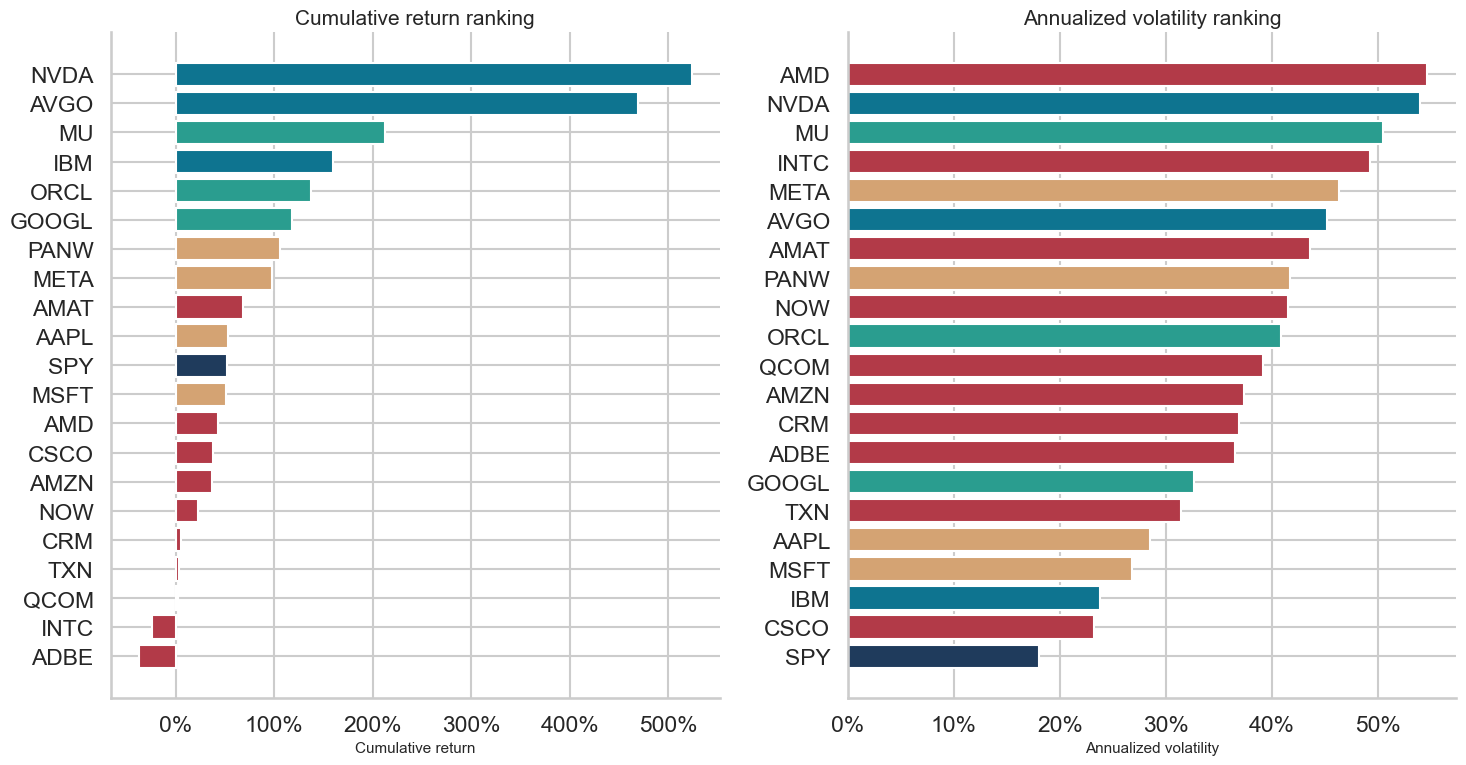

In [8]:
# Rank all names by cumulative return and annualized volatility.
# These ordered lists are used in the bar charts below.
ranked_returns = summary_table["Cumulative return"].sort_values()
ranked_volatility = summary_table["Annualized volatility"].sort_values()

# Create a two-panel figure:
# left panel = return ranking
# right panel = volatility ranking
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Choose bar colors based on each stock's screening status.
def bar_color(ticker):
    if ticker == BENCHMARK:
        return COLORS["benchmark"]
    status = recommendation_map.get(ticker, "Lower immediate priority")
    return {
        "Priority follow-up": COLORS["priority"],
        "Secondary follow-up": COLORS["secondary"],
        "Monitor with caution": COLORS["monitor"],
        "Lower immediate priority": COLORS["lower"],
    }[status]

# Plot the cumulative return ranking.
return_colors = [bar_color(ticker) for ticker in ranked_returns.index]
axes[0].barh(ranked_returns.index, ranked_returns.values, color=return_colors)
axes[0].set_title("Cumulative return ranking")
axes[0].set_xlabel("Cumulative return")
axes[0].xaxis.set_major_formatter(lambda value, pos: f"{value * 100:.0f}%")
style_axes(axes[0])

# Plot the annualized volatility ranking.
vol_colors = [bar_color(ticker) for ticker in ranked_volatility.index]
axes[1].barh(ranked_volatility.index, ranked_volatility.values, color=vol_colors)
axes[1].set_title("Annualized volatility ranking")
axes[1].set_xlabel("Annualized volatility")
axes[1].xaxis.set_major_formatter(lambda value, pos: f"{value * 100:.0f}%")
style_axes(axes[1])

# Render the figure.
plt.tight_layout()
plt.show()

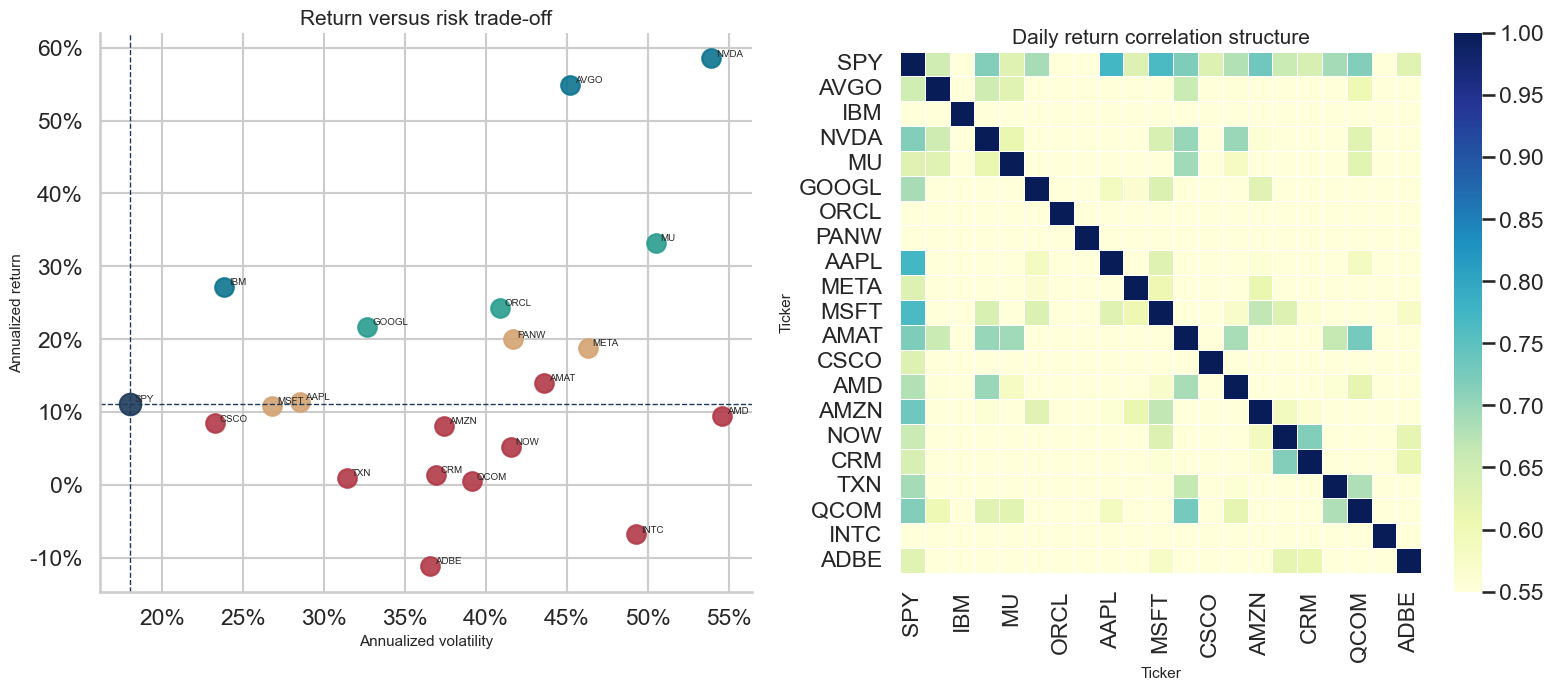

In [9]:
# Create a second two-panel figure:
# left panel = return-versus-risk scatter plot
# right panel = correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Define the color mapping for the screening categories.
recommendation_colors = {
    "Priority follow-up": COLORS["priority"],
    "Secondary follow-up": COLORS["secondary"],
    "Monitor with caution": COLORS["monitor"],
    "Lower immediate priority": COLORS["lower"],
}

# Start from the final watchlist table and add the benchmark back in.
scatter_frame = final_watchlist.copy()
scatter_frame.loc[BENCHMARK] = summary_table.loc[BENCHMARK]
scatter_frame.loc[BENCHMARK, "Committee status"] = "Benchmark"
scatter_frame.loc[BENCHMARK, "Screen rationale"] = "Reference point for the full market."

# Plot each name as one point on the risk/return chart.
for ticker, row in scatter_frame.iterrows():
    color = COLORS["benchmark"] if ticker == BENCHMARK else recommendation_colors.get(row["Committee status"], COLORS["neutral"])
    size = 240 if ticker == BENCHMARK else 180
    axes[0].scatter(
        row["Annualized volatility"],
        row["Annualized return"],
        s=size,
        color=color,
        alpha=0.9,
    )
    axes[0].text(
        row["Annualized volatility"] + 0.003,
        row["Annualized return"] + 0.003,
        ticker,
        fontsize=7,
    )

# Draw benchmark reference lines to show where the market sits on both axes.
axes[0].axvline(summary_table.loc[BENCHMARK, "Annualized volatility"], color=COLORS["benchmark"], linestyle="--", linewidth=1)
axes[0].axhline(summary_table.loc[BENCHMARK, "Annualized return"], color=COLORS["benchmark"], linestyle="--", linewidth=1)
axes[0].set_title("Return versus risk trade-off")
axes[0].set_xlabel("Annualized volatility")
axes[0].set_ylabel("Annualized return")
axes[0].xaxis.set_major_formatter(lambda value, pos: f"{value * 100:.0f}%")
axes[0].yaxis.set_major_formatter(lambda value, pos: f"{value * 100:.0f}%")
style_axes(axes[0])

# Plot a heatmap of daily return correlations for the full peer group.
sns.heatmap(
    correlation_matrix.loc[[BENCHMARK, *ranking.index.tolist()], [BENCHMARK, *ranking.index.tolist()]],
    annot=False,
    cmap="YlGnBu",
    vmin=0.55,
    vmax=1.00,
    linewidths=0.5,
    cbar=True,
    square=True,
    ax=axes[1],
)
axes[1].set_title("Daily return correlation structure")

# Render the figure.
plt.tight_layout()
plt.show()

## 9. Interpretation for the Investment Committee

The screen is only useful if the results can be translated into an actionable read-out. The summary below turns the charts and tables into the points most likely to matter in the committee discussion.


In [10]:
# Identify a few key facts that will be used in the written interpretation.
top_return_name = tech_summary["Cumulative return"].idxmax()
top_return_row = tech_summary.loc[top_return_name]

top_score_name = ranking.index[0]
top_score_row = ranking.loc[top_score_name]

# Find the lowest-volatility name among those that still beat the benchmark.
stable_outperformer = (
    tech_summary[tech_summary[f"Excess return vs {BENCHMARK}"] > 0]
    .sort_values(["Annualized volatility", "Max drawdown"], ascending=[True, False])
    .index[0]
)
stable_row = tech_summary.loc[stable_outperformer]

# Find the weakest name on a simple risk-adjusted basis.
laggard_name = tech_summary["Risk-adjusted return"].idxmin()
laggard_row = tech_summary.loc[laggard_name]

# Count how many technology names actually beat the benchmark.
outperformer_count = int((tech_summary[f"Excess return vs {BENCHMARK}"] > 0).sum())

# Build the interpretation block in business language.
interpretation = f'''
**Committee read-out**

- Only **{outperformer_count} of {len(WATCHLIST)}** technology names beat **{BENCHMARK}** over the window. The opportunity set was therefore selective rather than broad-based.
- **{top_return_name}** was the standout upside leader, compounding to **{pct(top_return_row['Cumulative return'])}** and beating **{BENCHMARK}** by **{pct(top_return_row[f'Excess return vs {BENCHMARK}'])}**. The same name also carried a much rougher path than the steadier compounders.
- **{top_score_name}** ranked highest on the composite screen because it paired strong excess return with stronger path quality than the most volatile winners.
- **{stable_outperformer}** emerged as the most stable benchmark-beater in the peer set, with annualized volatility of **{pct(stable_row['Annualized volatility'])}** and a maximum drawdown of **{pct(stable_row['Max drawdown'])}**. That profile matters for a committee that may not want the shortlist to lean only on high-beta names.
- **{laggard_name}** was the weakest screen outcome on a risk-adjusted basis at **{laggard_row['Risk-adjusted return']:.2f}**. It remains part of the comparison set, but not of the immediate first-round follow-up.
'''

# Display the interpretation as notebook markdown.
display(Markdown(interpretation))


**Committee read-out**

- Only **10 of 20** technology names beat **SPY** over the window. The opportunity set was therefore selective rather than broad-based.
- **NVDA** was the standout upside leader, compounding to **523.8%** and beating **SPY** by **471.8%**. The same name also carried a much rougher path than the steadier compounders.
- **AVGO** ranked highest on the composite screen because it paired strong excess return with stronger path quality than the most volatile winners.
- **IBM** emerged as the most stable benchmark-beater in the peer set, with annualized volatility of **23.8%** and a maximum drawdown of **-19.8%**. That profile matters for a committee that may not want the shortlist to lean only on high-beta names.
- **ADBE** was the weakest screen outcome on a risk-adjusted basis at **-0.31**. It remains part of the comparison set, but not of the immediate first-round follow-up.


## 10. Final Screening Recommendation

The table below converts the quantitative screen into a practical watchlist. The categories are intentionally simple: names to move into deeper follow-up, names worth monitoring with more caution, and names that do not currently deserve front-of-queue attention based on this historical screen alone.


In [11]:
# Keep only the final shortlist names for the executive recommendation table.
executive_table = final_watchlist.loc[
    shortlist_names,
    [
        "Committee status",
        "Cumulative return",
        "Annualized volatility",
        "Max drawdown",
        f"Excess return vs {BENCHMARK}",
        "Screen rationale",
    ],
].copy()

# Format the key numeric fields as readable percentages.
executive_table_display = format_table(
    executive_table,
    [
        "Cumulative return",
        "Annualized volatility",
        "Max drawdown",
        f"Excess return vs {BENCHMARK}",
    ],
)

# Display the final executive table.
display(executive_table_display)

# Write the concluding recommendation in business language.
conclusion = f'''
**Recommended first watchlist**

Priority follow-up should begin with **{', '.join(priority_names)}**. These were the strongest composite screens in the full universe and deserve the next layer of fundamental work first.

A second line of follow-up can stay with **{', '.join(secondary_names)}**, which remain credible first-round survivors even if they were less decisive than the top tier. **{', '.join(monitor_names)}** are still useful monitoring names, while **{', '.join(lower_priority_names[:5])}** and the rest of the lower tier move to the back of the queue for now.

This remains a first quantitative filter. Any investment decision would still require valuation work, earnings and capital-allocation review, and a current assessment of business-specific catalysts.
'''

# Display the conclusion as markdown so it reads like an analyst note.
display(Markdown(conclusion))

,Committee status,Cumulative return,Annualized volatility,Max drawdown,Excess return vs SPY,Screen rationale
Ticker,,,,,,
AVGO,Priority follow-up,469.4%,45.2%,-41.1%,417.3%,"Top-tier screen: 469.4% cumulative return, 417..."
IBM,Priority follow-up,160.0%,23.8%,-19.8%,108.0%,"Top-tier screen: 160.0% cumulative return, 108..."
NVDA,Priority follow-up,523.8%,53.9%,-62.7%,471.8%,"Top-tier screen: 523.8% cumulative return, 471..."
MU,Secondary follow-up,212.5%,50.5%,-57.6%,160.4%,Strong enough to stay in the first-round short...
GOOGL,Secondary follow-up,118.1%,32.7%,-43.6%,66.1%,Strong enough to stay in the first-round short...
ORCL,Secondary follow-up,136.9%,40.9%,-45.6%,84.8%,Strong enough to stay in the first-round short...



**Recommended first watchlist**

Priority follow-up should begin with **AVGO, IBM, NVDA**. These were the strongest composite screens in the full universe and deserve the next layer of fundamental work first.

A second line of follow-up can stay with **MU, GOOGL, ORCL**, which remain credible first-round survivors even if they were less decisive than the top tier. **PANW, AAPL, META, MSFT** are still useful monitoring names, while **AMAT, CSCO, AMD, AMZN, NOW** and the rest of the lower tier move to the back of the queue for now.

This remains a first quantitative filter. Any investment decision would still require valuation work, earnings and capital-allocation review, and a current assessment of business-specific catalysts.
